**HW 5 - Logistic Regression**

**Minh Truong**

**1412225**

In [44]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc

**Get the dataset from the Logistic Regressions Dataset folder**

I chose the "loan_data.csv" dataset.

**1. Load the .csv file into a data frame in Python.**

In [45]:
# Load the dataset
df = pd.read_csv('loan_data.csv')

# Display the first 5 rows
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


**2. Describe the data, provide information on the dataset**

In [46]:
# Display dataset shape
print(f"Dataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Dataset Shape: (45000, 14)
Rows: 45000, Columns: 14


In [47]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [48]:
# Statistical summary of the dataset
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [49]:
# Check for missing values
print(df.isnull().sum())

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64


In [50]:
# Check for duplicate rows
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


**3. Conduct Logistic Regression**

In this scenario we are conducting logistic regression to predict loan approval status (0 = Denied, 1 = Approved).

**4. Preprocess data if needed**

In [51]:
# Step 1: Identify the target variable
target = 'loan_status' # 0 (denied) or 1 (approved)

# Display how many loans were approved vs denied
print(f"\nClass Distribution:")
print(df[target].value_counts()) # Count of 0s and 1s


Class Distribution:
loan_status
0    35000
1    10000
Name: count, dtype: int64


In [52]:
# Encode categorical variables

# Step 2: Find all categorical (text-based) columns
categorical_cols = df.select_dtypes(include=['object']).columns # select_dtypes finds columns with 'object' type (text/strings)

# Step 3: Create a copy for preprocessing and to preserve the original data
df_processed = df.copy()

# Step 4: Encode each categorical column (convert text to numbers)
for col in categorical_cols: # Loop through each categorical column
    le = LabelEncoder() # Create a LabelEncoder object for this column
    df_processed[col] = le.fit_transform(df_processed[col]) # Transform the column (text to numbers)

In [53]:
# Step 5: Separate features (X) and target (y)
X = df_processed.drop(columns=[target]) # X = all columns EXCEPT the target (inputs values)
y = df_processed[target] # y = only the target column 

print(f"Features shape: {X.shape}") # Shows (number_of_rows, number_of_features)
print(f"Target shape: {y.shape}") # Shows (number_of_rows,)

Features shape: (45000, 13)
Target shape: (45000,)


**5. Print the correlation coefficient matrix**

In [54]:
# Compute correlation matrix
correlation = df_processed.corr()
print(correlation)

                                person_age  person_gender  person_education  \
person_age                        1.000000       0.017528         -0.014649   
person_gender                     0.017528       1.000000         -0.002267   
person_education                 -0.014649      -0.002267          1.000000   
person_income                     0.193698       0.010173          0.000331   
person_emp_exp                    0.954412       0.015078         -0.012034   
person_home_ownership            -0.039008      -0.001172         -0.000290   
loan_amnt                         0.050750       0.010647         -0.002441   
loan_intent                       0.032005      -0.003107          0.004356   
loan_int_rate                     0.013402       0.003662          0.000336   
loan_percent_income              -0.043299      -0.000367         -0.006984   
cb_person_cred_hist_length        0.861985       0.011999         -0.014576   
credit_score                      0.178432      -0.0

In [55]:
# Display correlation with target variable
# Show which features correlate most with our target (loan_status)
print("\nCorrelation with Target Variable (loan_status):")

# Sort by correlation strength (highest to lowest)
print(correlation[target].sort_values(ascending=False))


Correlation with Target Variable (loan_status):
loan_status                       1.000000
loan_percent_income               0.384880
loan_int_rate                     0.332005
person_home_ownership             0.233842
loan_amnt                         0.107714
person_gender                    -0.000561
person_education                 -0.001747
credit_score                     -0.007647
cb_person_cred_hist_length       -0.014851
person_emp_exp                   -0.020481
person_age                       -0.021476
loan_intent                      -0.072158
person_income                    -0.135808
previous_loan_defaults_on_file   -0.543096
Name: loan_status, dtype: float64


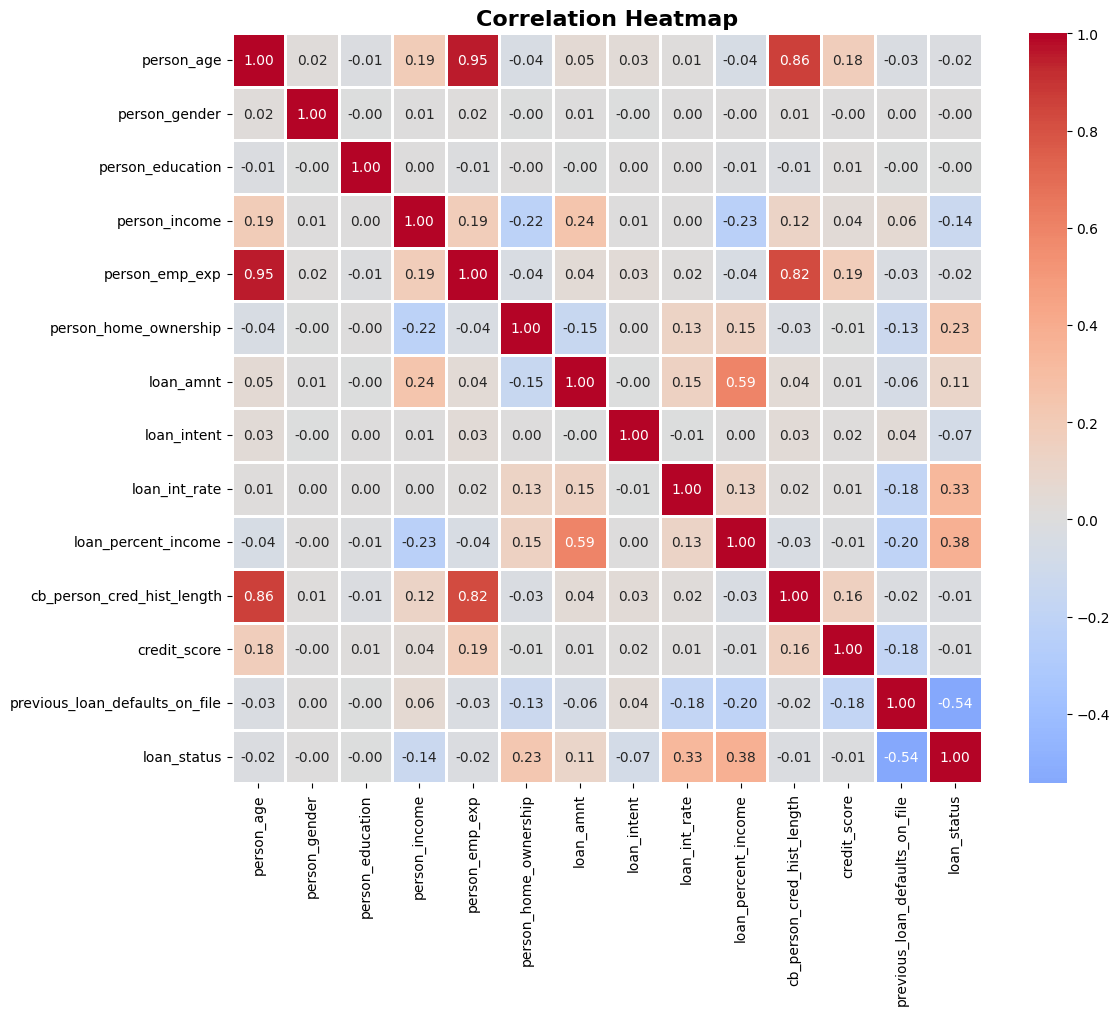

In [56]:
# Create a heatmap to visualize correlations
plt.figure(figsize=(12, 10))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1)
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**6. Normalize data using appropriate scaling**

In [57]:
# Apply StandardScaler for normalization

# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler to training data and transform it
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame to keep column names
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Data normalized using StandardScaler (mean=0, std=1)")
print("\nScaled Data Statistics:")
print(X_scaled.describe())

Data normalized using StandardScaler (mean=0, std=1)

Scaled Data Statistics:
         person_age  person_gender  person_education  person_income  \
count  4.500000e+04   4.500000e+04      4.500000e+04   4.500000e+04   
mean  -1.212660e-16   1.098973e-16     -6.063298e-17  -4.547474e-17   
std    1.000011e+00   1.000011e+00      1.000011e+00   1.000011e+00   
min   -1.284388e+00  -1.110069e+00     -1.179025e+00  -8.992491e-01   
25%   -6.226885e-01  -1.110069e+00     -1.179025e+00  -4.117681e-01   
50%   -2.918388e-01   9.008448e-01     -5.029528e-01  -1.650185e-01   
75%    3.698606e-01   9.008448e-01      8.491920e-01   1.923637e-01   
max    1.922829e+01   9.008448e-01      1.525264e+00   8.853898e+01   

       person_emp_exp  person_home_ownership     loan_amnt   loan_intent  \
count    45000.000000           4.500000e+04  4.500000e+04  4.500000e+04   
mean         0.000000          -2.526374e-17  1.515825e-17 -8.715991e-17   
std          1.000011           1.000011e+00  1.000011

**7. Train the model - Randomly sample 80% of each dataset and save them in a training dataset and save the remaining 20% of each dataset in a testing dataset.**

In [58]:
# Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

**8. Split the list of labels accordingly**

In [59]:
# Display label distribution
print("Training set class distribution:")
print(y_train.value_counts())
print("\nTesting set class distribution:")
print(y_test.value_counts())

Training set class distribution:
loan_status
0    28000
1     8000
Name: count, dtype: int64

Testing set class distribution:
loan_status
0    7000
1    2000
Name: count, dtype: int64


In [60]:
# Train Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


**9. Create a confusion matrix to compare the predicted state activities to the actual activities and compute the accuracy.**

In [62]:
# Make predictions on test set

# Use the trained model to make predictions on test data
y_pred = model.predict(X_test) # Predicted classes (0 or 1)
y_pred_proba = model.predict_proba(X_test) # Predicted probabilities

# Calculate accuracy: percentage of correct predictions
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.8968


In [63]:
# Create confusion matrix

# Shows: How many we got right vs wrong, and what type of errors
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
print("\n[[True Negative  False Positive]")
print("[False Negative True Positive]]")


Confusion Matrix:
[[6572  428]
 [ 501 1499]]

[[True Negative  False Positive]
[False Negative True Positive]]


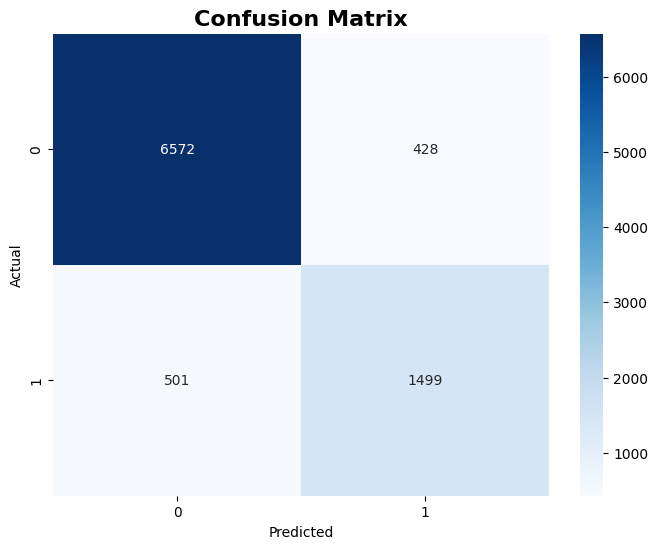

In [64]:
# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

**10. Make Predictions**

In [65]:
# Display sample predictions
print("Sample Predictions (first 20):")
predictions_df = pd.DataFrame({
    'Actual': y_test.values[:20],
    'Predicted': y_pred[:20],
    'Match': y_test.values[:20] == y_pred[:20]
})
print(predictions_df)
print(f"\nTotal predictions made: {len(y_pred)}")

Sample Predictions (first 20):
    Actual  Predicted  Match
0        0          0   True
1        0          0   True
2        0          0   True
3        0          0   True
4        1          0  False
5        1          1   True
6        0          0   True
7        0          0   True
8        0          0   True
9        0          0   True
10       0          0   True
11       0          0   True
12       0          0   True
13       0          1  False
14       0          0   True
15       0          1  False
16       0          0   True
17       0          0   True
18       0          0   True
19       0          0   True

Total predictions made: 9000


**11. Evaluate the model**

In [66]:
# Display classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      7000
           1       0.78      0.75      0.76      2000

    accuracy                           0.90      9000
   macro avg       0.85      0.84      0.85      9000
weighted avg       0.90      0.90      0.90      9000



In [67]:
# Calculate detailed metrics
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("\nDetailed Performance Metrics:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")


Detailed Performance Metrics:
Accuracy:  0.8968
Precision: 0.8956
Recall:    0.8968
F1-Score:  0.8961


In [68]:
# Calculate ROC-AUC score
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.9514


In [69]:
# Feature importance (coefficients)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})
feature_importance['Abs_Coefficient'] = abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

print("\nTop 5 Most Important Features:")
print(feature_importance[['Feature', 'Coefficient']].head())


Top 5 Most Important Features:
                           Feature  Coefficient
12  previous_loan_defaults_on_file    -4.539919
9              loan_percent_income     1.243245
8                    loan_int_rate     0.983869
6                        loan_amnt    -0.538459
11                    credit_score    -0.446545


**13. Generate relevant graphs**

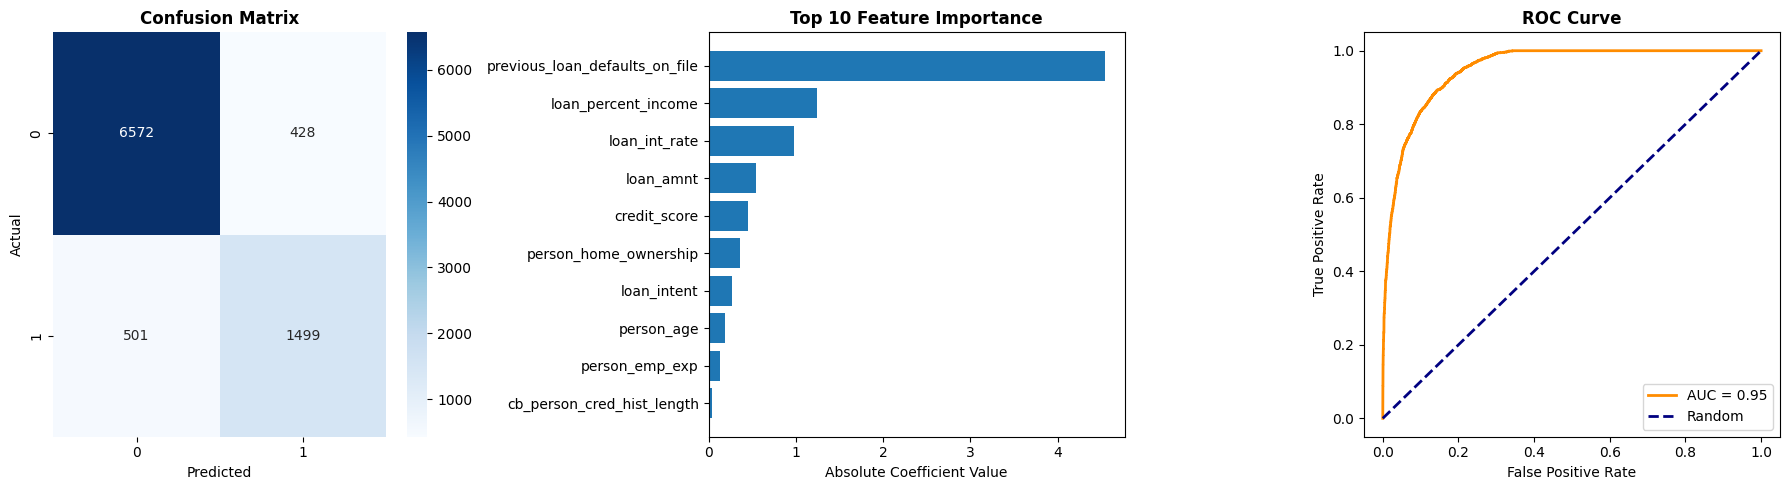

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graph 1: Confusion Matrix
# This graph shows how many predictions were correct vs incorrect
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Graph 2: Feature Importance
# This graph shows the most imfluential feautures on the model
top_features = feature_importance.head(10)
axes[1].barh(range(len(top_features)), top_features['Abs_Coefficient'])
axes[1].set_yticks(range(len(top_features)))
axes[1].set_yticklabels(top_features['Feature'])
axes[1].set_xlabel('Absolute Coefficient Value')
axes[1].set_title('Top 10 Feature Importance', fontweight='bold')
axes[1].invert_yaxis()

# Graph 3: ROC Curve
# This graph shows  how well the model separates approved vs denied loans.
fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])
axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
axes[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve', fontweight='bold')
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.show()

**Conclusion**

The logistic regression model achieved an accuracy of 89.68% in predicting loan approval status. Our model shows strong performance with a high precision of 89.56% and a recall of 89.68%. The most influential features for prediction are previous loan defaults on file, loan percent of income, loan interest rate, loan amount, and credit score.

1. True Negative (6572) means we correctly predicted the loan would be denied
2. False Positive (428) means we predicted the loan would be approved, but in reality it was denied
3. False Negative (501) means we predicted the loan would be denied but it was actually approved
4. True Positive (1499) means we correctly predicted the loan would be approved

The confusion matrix shows that the model correctly classifies the majority of both approved and denied loans, with a ROC-AUC score of 0.95. Generally, the closer the AUC score is to 1, the better the model. 